# Sketched Normal-Operator Products

This notebook demonstrates the sketched normal-operator primitives for low-rank recovery.

Given a low-rank iterate $X = U \operatorname{diag}(\sigma) V^T$ and the whitened forward model,
we compute $S_L G(X)$ and $G(X) Q_R$ without forming the dense gradient
$G(X) = A^*(A(X) - b)$.

**Sections:**
1. Generate / load PDB dataset
2. Sanity check: $X = X_{GT}$ with true coordinates $\Rightarrow G(X) = 0$
3. Sketch at scale (rank 10–200), timing
4. PPCA EM baseline for comparison
5. Plots: GT PCs, PPCA PCs, relvar

In [1]:
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr

import recovar.core.fourier_transform_utils as ftu
from recovar import utils
from recovar.core import linalg
from recovar.output import metrics
from recovar.simulation import simulator
from recovar.simulation.trajectory_generation import generate_trajectory_volumes
from recovar.ppca.ppca_scale_sweep import _load_simulated_dataset, _with_trailing_separator
from recovar.ppca import ppca as ppca_mod, prior_estimation
from recovar.ppca.sketched_normal import compute_normal_residual_sketches

print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


## Configuration

In [2]:
GRID_SIZE   = 128
N_IMAGES    = 100000
NOISE_LEVEL = 0.1
N_VOLUMES   = 10
N_PCS       = 10
SKETCH_RANK = 200
BATCH_SIZE  = 500
PPCA_ITERS  = 10
DISC_TYPE   = "linear_interp"

BASE_DIR = "/scratch/gpfs/GILLES/mg6942/tmp/sketch_notebook"
os.makedirs(BASE_DIR, exist_ok=True)

## 1. Generate / Load Dataset

In [3]:
voxel_size = 4.25 * 128 / GRID_SIZE
vol_prefix = os.path.join(BASE_DIR, "generated_volumes", "vol")
ds_dir = os.path.join(BASE_DIR, "test_dataset")

# Generate volumes
if not os.path.isfile(f"{vol_prefix}0000.mrc"):
    print(f"Generating {N_VOLUMES} trajectory volumes (grid={GRID_SIZE}) ...")
    generate_trajectory_volumes(
        BASE_DIR, grid_size=GRID_SIZE, n_volumes=N_VOLUMES,
        voxel_size=voxel_size, Bfactor=80, max_rotation_degrees=10.0,
    )
else:
    print(f"Reusing volumes at {vol_prefix}")

# Generate dataset
if not os.path.isfile(os.path.join(ds_dir, f"particles.{GRID_SIZE}.mrcs")):
    print(f"Simulating dataset: n={N_IMAGES}, noise={NOISE_LEVEL} ...")
    np.random.seed(42)
    simulator.generate_synthetic_dataset(
        ds_dir, voxel_size, vol_prefix, N_IMAGES,
        grid_size=GRID_SIZE,
        noise_level=NOISE_LEVEL, noise_model="radial1",
        contrast_std=0.0, noise_scale_std=0.0,
        dataset_params_option="uniform", disc_type=DISC_TYPE,
        trailing_zero_format_in_vol_name=True,
        put_extra_particles=False, percent_outliers=0.0,
    )
else:
    print(f"Reusing dataset at {ds_dir}")

# Load
cryo, sim_info, gt, noise_var = _load_simulated_dataset(
    _with_trailing_separator(ds_dir), GRID_SIZE, N_IMAGES, lazy=False,
)
vs = cryo.volume_shape
half_vs = ftu.volume_shape_to_half_volume_shape(vs)
half_vol_size = int(np.prod(half_vs))
vol_size = int(np.prod(vs))
n_images = cryo.n_images
print(f"Loaded: grid={cryo.grid_size}, n_images={n_images}, half_vol={half_vol_size}")

Generating 10 trajectory volumes (grid=128) ...


/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)


/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)


/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)


/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)


...

/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)


/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)


/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)


Simulating dataset: n=100000, noise=0.1 ...


Loaded: grid=128, n_images=100000, half_vol=1064960


In [4]:
# GT eigenvectors, eigenvalues, mean
U_gt_all, s_gt_all, _ = gt.get_vol_svd()
U_gt = U_gt_all[:, :N_PCS]
s_gt = s_gt_all[:N_PCS]
gt_mean = gt.get_mean()

# Half-volume versions
U_gt_half = np.asarray(ftu.full_volume_to_half_volume(U_gt.T, vs).T)
mean_half = np.asarray(ftu.full_volume_to_half_volume(gt_mean.reshape(vs), vs).reshape(-1))

# True per-image coordinates from GT assignment
assign = np.array(sim_info["image_assignment"])
centered_vols = np.asarray(gt.volumes - gt_mean[None, :])
state_coords = (np.conj(centered_vols) @ np.asarray(U_gt)) / np.asarray(s_gt)
V_true = state_coords[assign].real.astype(np.float32)

print(f"GT: {N_PCS} PCs, top eigenvalues: {s_gt[:5]}")
print(f"V_true shape: {V_true.shape}, range: [{V_true.min():.2f}, {V_true.max():.2f}]")

GT: 10 PCs, top eigenvalues: [13924.68072531  7519.27855536  3937.8880233   2142.8471508
  1039.86034999]
V_true shape: (100000, 10), range: [-1.70, 1.69]


## 2. Sanity Check: $X = X_{GT} \Rightarrow G(X) \approx 0$

If $b_i = A_i(x_i)$ for all images, then the normal residual $G(X) = A^*(A(X) - b) = 0$.

In practice, the residual is nonzero due to noise in the images (noise_level > 0).

In [5]:
rng = np.random.default_rng(0)
Q_test = rng.normal(size=(n_images, 3)).astype(np.float32)

result_sanity = compute_normal_residual_sketches(
    cryo, U_gt_half, s_gt.astype(np.float32), V_true, mean_half,
    batch_size=BATCH_SIZE, right_sketch=Q_test, disc_type=DISC_TYPE,
)
sanity_norm = float(np.linalg.norm(np.asarray(result_sanity["right"])))
print(f"||G(X_gt) @ Q|| = {sanity_norm:.4f}")
print(f"This is nonzero because images contain noise (noise_level={NOISE_LEVEL}).")
print(f"The sketch measures how far X is from the data-consistent solution.")

||G(X_gt) @ Q|| = 204.2374
This is nonzero because images contain noise (noise_level=0.1).
The sketch measures how far X is from the data-consistent solution.


## 3. Sketch at Scale — Timing vs sketch_rank

Uses `per_image_backproject` (one CUDA call per batch) + matmul.
Cost is $O(\text{batch})$ backprojections regardless of sketch_rank.

In [6]:
sketch_ranks = [10, 20, 50, 100, 200]
timings = []

for sr in sketch_ranks:
    S = (rng.normal(size=(sr, half_vol_size))
         + 1j * rng.normal(size=(sr, half_vol_size))).astype(np.complex64)
    Q = rng.normal(size=(n_images, sr)).astype(np.float32)

    # Warmup (JIT compile)
    r = compute_normal_residual_sketches(
        cryo, U_gt_half, s_gt.astype(np.float32), V_true, mean_half,
        batch_size=BATCH_SIZE, left_sketch_half=S, right_sketch=Q,
        disc_type=DISC_TYPE,
    )
    jax.block_until_ready(r["left"]); jax.block_until_ready(r["right"])

    # Timed
    t0 = time.time()
    r = compute_normal_residual_sketches(
        cryo, U_gt_half, s_gt.astype(np.float32), V_true, mean_half,
        batch_size=BATCH_SIZE, left_sketch_half=S, right_sketch=Q,
        disc_type=DISC_TYPE,
    )
    jax.block_until_ready(r["left"]); jax.block_until_ready(r["right"])
    dt = time.time() - t0
    timings.append(dt)

    ln = float(np.linalg.norm(np.asarray(r["left"])))
    rn = float(np.linalg.norm(np.asarray(r["right"])))
    print(f"sketch_rank={sr:4d}  time={dt:6.1f}s  left_norm={ln:.1f}  right_norm={rn:.1f}")

/scratch/gpfs/GILLES/mg6942/recovar_wt_sketched_v2/.pixi/envs/default/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


sketch_rank=  10  time=   8.1s  left_norm=372.6  right_norm=372.6


sketch_rank=  20  time=   8.5s  left_norm=527.2  right_norm=527.2


sketch_rank=  50  time=  10.7s  left_norm=833.4  right_norm=833.4


sketch_rank= 100  time=  14.5s  left_norm=1178.7  right_norm=1177.8


sketch_rank= 200  time=  21.8s  left_norm=1667.0  right_norm=1666.4


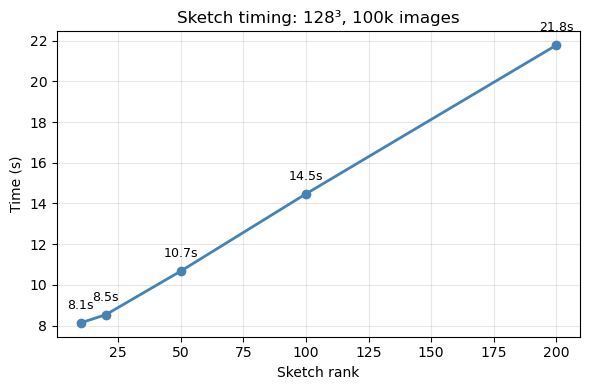

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sketch_ranks, timings, "o-", color="steelblue", linewidth=2, markersize=6)
for sr, dt in zip(sketch_ranks, timings):
    ax.annotate(f"{dt:.1f}s", (sr, dt), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_xlabel("Sketch rank")
ax.set_ylabel("Time (s)")
ax.set_title(f"Sketch timing: {GRID_SIZE}³, {N_IMAGES//1000}k images")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. PPCA EM Baseline

No contrast, no mask, `linear_interp` everywhere, GT mean, GT prior.
This gives a reference relvar for comparison.

W_prior shape=(2097152, 10), median=9.74e+00

EM ALGORITHM CONVERGENCE TABLE (WITHOUT WHITENING)
Iter | Neg_LL_Total |  Neg_LL_Data | Neg_LL_Prior |  Exp_ZS_Mean |   Exp_ZS_Var | Rel_Var_Expl |        Top_5_Rel_Var
---------------------------------------------------------------------------------------------------------------------


   0 | 2.337341e+09 | 2.337341e+09 | 3.431263e+01 | 2.239558e-06 | 3.509298e-06 | 2.496689e-02 | [0.02451509 0.02451565 0.02454772 0.02455629 0.02467641]


   1 | 2.331562e+09 | 2.331560e+09 | 1.241735e+03 | 2.959524e-05 | 5.744488e-04 | 4.119741e-01 | [0.4029561  0.40310109 0.40346996 0.40487966 0.40714384]


   2 | 2.331784e+09 | 2.331471e+09 | 3.125422e+05 | 7.833961e-05 | 1.765397e-01 | 4.988235e-01 | [0.43702477 0.43755573 0.43893523 0.44606531 0.48713842]


   3 | 2.328667e+09 | 2.328371e+09 | 2.957282e+05 | 7.314380e-05 | 8.681171e-01 | 6.077751e-01 | [0.43505059 0.6040784  0.60557453 0.6057689  0.6066284 ]


...

   5 | 2.327936e+09 | 2.327282e+09 | 6.534350e+05 | 1.575918e-03 | 3.319768e+00 | 6.270773e-01 | [0.42998045 0.62170321 0.62676555 0.62683233 0.6268779 ]


   6 | 2.327703e+09 | 2.327037e+09 | 6.664398e+05 | 1.979331e-03 | 3.865758e+00 | 6.306726e-01 | [0.42938954 0.62179136 0.63040858 0.63047584 0.63049323]


   7 | 2.327719e+09 | 2.327046e+09 | 6.725345e+05 | 1.995626e-03 | 3.987368e+00 | 6.355602e-01 | [0.42939362 0.62203109 0.63540118 0.63543385 0.63544882]


   8 | 2.327720e+09 | 2.327041e+09 | 6.790981e+05 | 1.972375e-03 | 4.049314e+00 | 6.412352e-01 | [0.42948582 0.62223241 0.64112713 0.64114417 0.6411555 ]


   9 | 2.327710e+09 | 2.327025e+09 | 6.850979e+05 | 1.942157e-03 | 4.089447e+00 | 6.471003e-01 | [0.42958126 0.62239276 0.64701942 0.64702918 0.64703791]


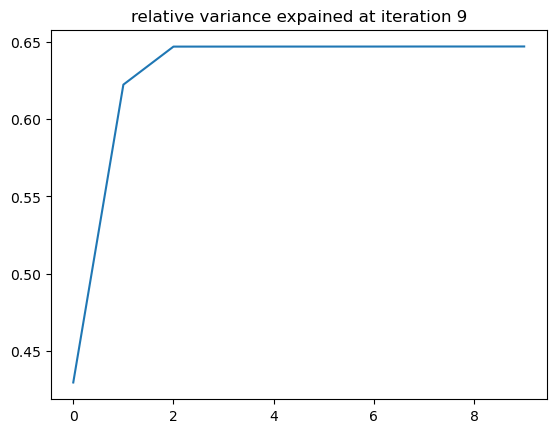

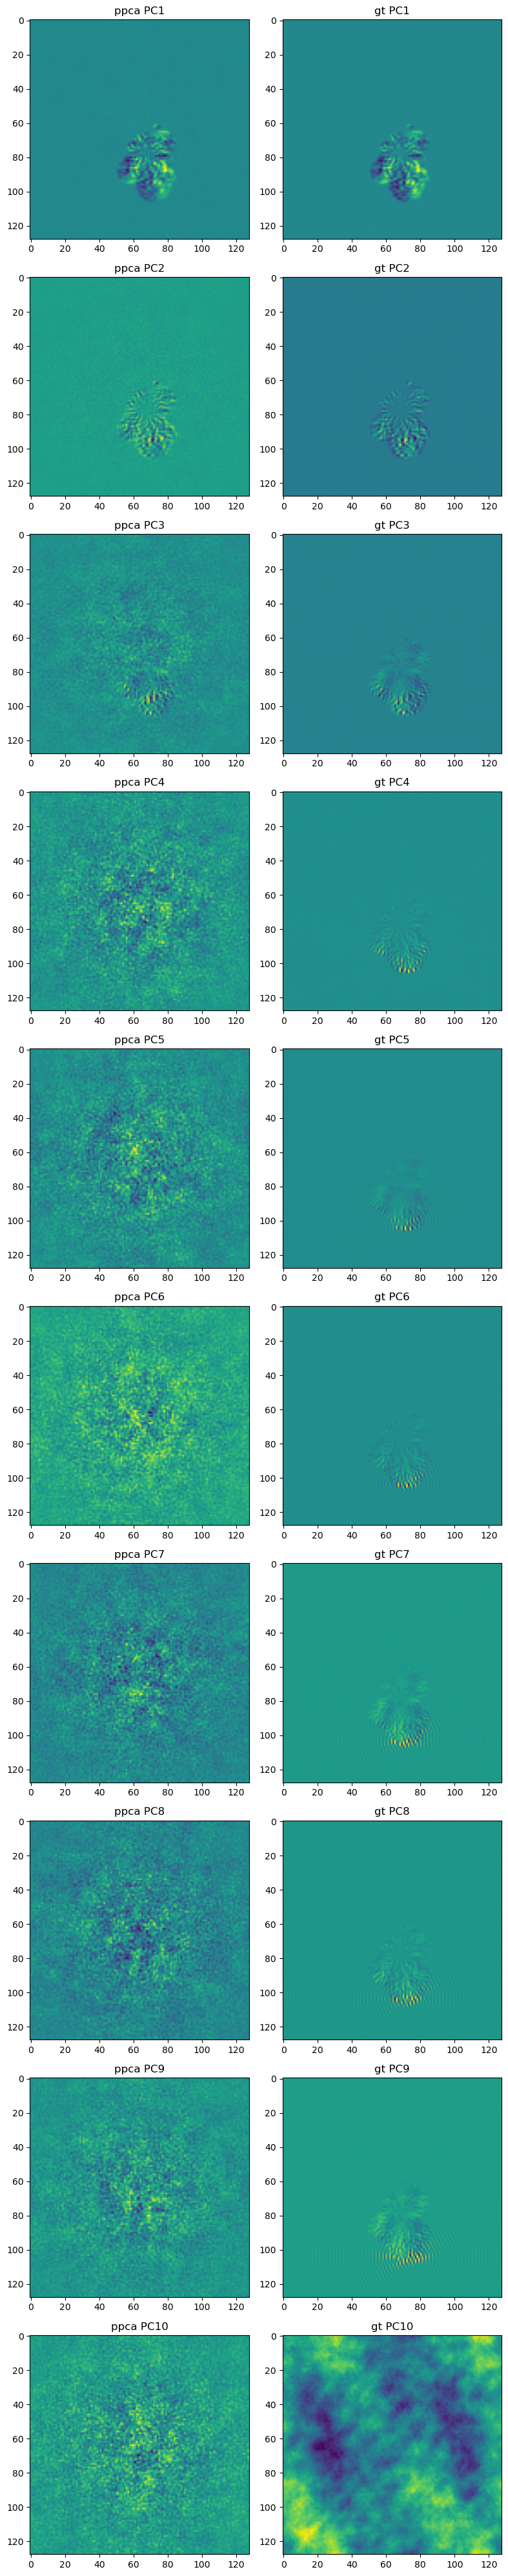

EM ALGORITHM COMPLETED
PPCA EM done in 122.0s


In [8]:
# Random initial W
W_init = jr.normal(jr.PRNGKey(0), (vol_size, N_PCS), dtype=jnp.float32)
W_init = linalg.batch_dft3(W_init, vs, N_PCS)

# GT prior
W_prior = prior_estimation.make_gt_prior_from_variance_total(
    gt.get_fourier_variances(contrasted=False), N_PCS, vs,
)["W_prior"]
print(f"W_prior shape={W_prior.shape}, median={np.median(W_prior):.2e}")

t0 = time.time()
U_ppca, S_ppca, W_ppca, _, _ = ppca_mod.EM(
    cryo, gt_mean, W_init, W_prior,
    EM_iter=PPCA_ITERS,
    U_gt=U_gt_all, S_gt=s_gt_all,
    disc_type_mean=DISC_TYPE, disc_type=DISC_TYPE,
    contrast_mode="none",
)
dt_ppca = time.time() - t0
print(f"PPCA EM done in {dt_ppca:.1f}s")

In [9]:
rv_ppca = metrics.captured_variance(U_ppca, U_gt_all, s_gt_all)
relvar_ppca = np.asarray(metrics.relative_variance_from_captured_variance(rv_ppca, s_gt_all))
print(f"PPCA relvar: {[f'{x:.4f}' for x in relvar_ppca]}")

PPCA relvar: ['0.4296', '0.6224', '0.6470', '0.6470', '0.6470', '0.6470', '0.6471', '0.6471', '0.6471', '0.6471']


## 5. Plots

In [10]:
def to_real(vol_ft, vs):
    return np.asarray(ftu.get_idft3(np.asarray(vol_ft).reshape(vs)).real)

def plot_slices(vols_real, labels, title):
    n = len(vols_real)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1: axes = [axes]
    for i, (v, l) in enumerate(zip(vols_real, labels)):
        mid = v.shape[2] // 2
        im = axes[i].imshow(v[:, :, mid], cmap="RdBu_r")
        axes[i].set_title(l, fontsize=9); axes[i].axis("off")
        plt.colorbar(im, ax=axes[i], fraction=0.046)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()

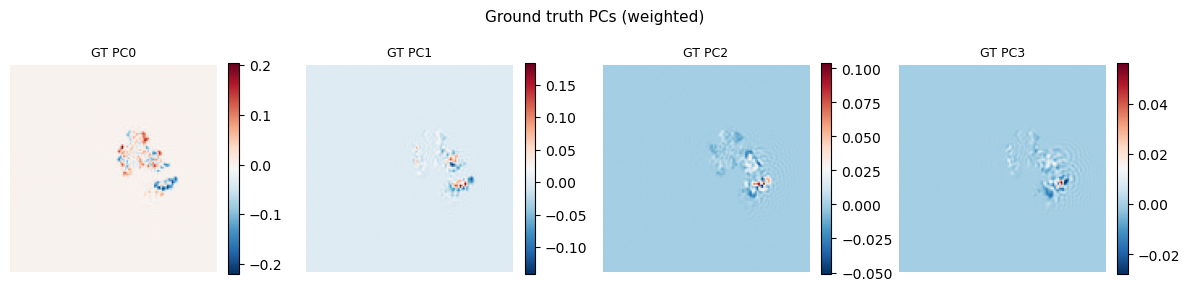

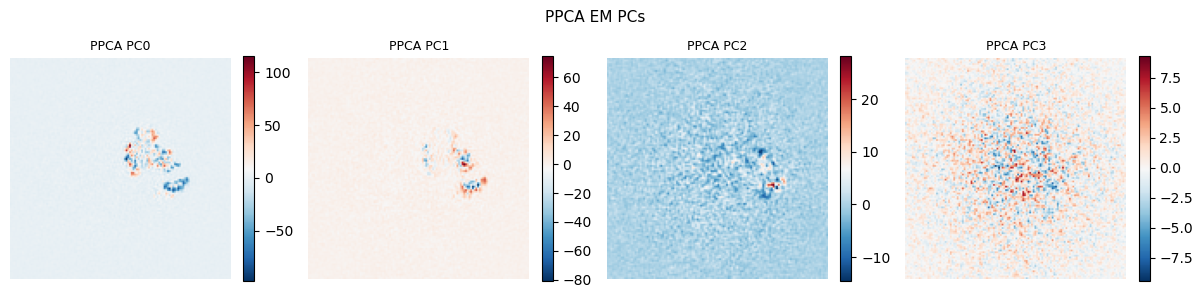

In [11]:
n_show = min(4, N_PCS)
gt_real = [to_real(U_gt_all[:, k] * s_gt_all[k], vs) for k in range(n_show)]
ppca_real = [to_real(U_ppca[:, k] * S_ppca[k], vs) for k in range(n_show)]

plot_slices(gt_real, [f"GT PC{k}" for k in range(n_show)], "Ground truth PCs (weighted)")
plot_slices(ppca_real, [f"PPCA PC{k}" for k in range(n_show)], "PPCA EM PCs")

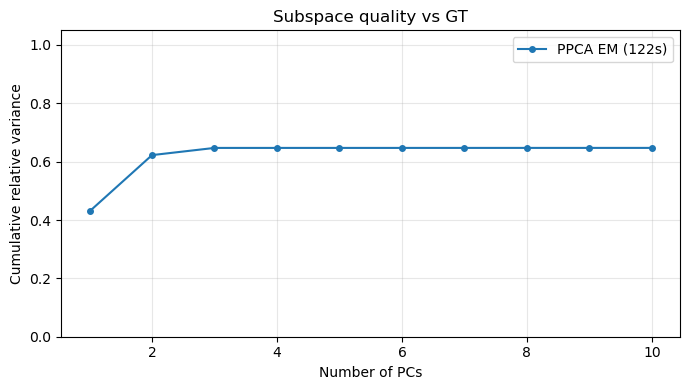

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(relvar_ppca) + 1), relvar_ppca, "o-",
        label=f"PPCA EM ({dt_ppca:.0f}s)", markersize=4)
ax.set_xlabel("Number of PCs")
ax.set_ylabel("Cumulative relative variance")
ax.set_title("Subspace quality vs GT")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

The sketch primitives are in `recovar.ppca.sketched_normal`:

```python
from recovar.ppca.sketched_normal import compute_normal_residual_sketches

result = compute_normal_residual_sketches(
    cryo, U_X_half, sigma_X, V_X, mean_half,
    batch_size=500,
    left_sketch_half=S_left,   # (s, half_vol) → returns (s, n_images)
    right_sketch=Q_right,       # (n_images, t) → returns (half_vol, t)
)
```

Use these to build a sketched PC algorithm on top.